## 1. Load and Prepare the Dataset

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

# Function to load data from a text file
def load_data(file_path, label):
    data = np.loadtxt(file_path)
    labels = np.full(data.shape[0], label)  # Assign the class label
    return data, labels

# Load data for each class
X1, y1 = load_data('RD_data/class1.txt', label=1)
X2, y2 = load_data('RD_data/class2.txt', label=2)
X3, y3 = load_data('RD_data/class3.txt', label=3)

# Combine all data into a single dataset
X = np.vstack((X1, X2, X3))
y = np.hstack((y1, y2, y3))

# Split each class into 70% training and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Now we have X_train, X_test, y_train, and y_test
print(X_train, X_test, y_train, y_test)


[[ 425.78125 2042.96875]
 [ 734.375   1183.59375]
 [ 421.875   2085.9375 ]
 ...
 [ 519.53125 2074.21875]
 [ 347.65625  707.03125]
 [ 382.8125   804.6875 ]] [[ 746.09375 1304.6875 ]
 [ 687.5     1082.03125]
 [ 441.40625 2062.5    ]
 ...
 [ 347.65625  652.34375]
 [ 710.9375  1132.8125 ]
 [ 406.25    2242.1875 ]] [1 3 1 ... 1 2 2] [3 3 1 ... 2 3 1]


## 2. Implement K-Means for GMM Initialization

In [13]:
# Define the K-means initialization function
def initialize_kmeans(X, k, max_iters=100):
    # Randomly initialize k cluster centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Assign each point to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Update centroids by taking the mean of assigned points
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # If centroids do not change, break
        if np.all(centroids == new_centroids):
            break

        centroids = new_centroids

    return centroids, labels



## 3. Implement GMM with Expectation-Maximization (EM)

In [8]:
def gaussian_density(x, mean, cov):
    d = x.shape[0]
    cov_inv = np.linalg.inv(cov)
    norm_const = 1.0 / np.sqrt((2 * np.pi)**d * np.linalg.det(cov))
    diff = x - mean
    return norm_const * np.exp(-0.5 * np.dot(diff.T, np.dot(cov_inv, diff)))


def gmm_em(X, k, max_iters=100, tol=1e-6, epsilon=1e-8):
    n, d = X.shape

    # Initialize means using K-means
    means, _ = initialize_kmeans(X, k)
    # Initialize covariances as identity matrices
    covariances = [np.eye(d) for _ in range(k)]
    # Initialize mixing coefficients
    weights = np.ones(k) / k
    likelihoods = []

    for iteration in range(max_iters):
        # E-step: Calculate responsibilities (gamma)
        gamma = np.zeros((n, k))

        for i in range(k):
            for j in range(n):
                gamma[j, i] = weights[i] * gaussian_density(X[j], means[i], covariances[i])

        # Normalize responsibilities, add epsilon to avoid division by zero
        gamma_sum = gamma.sum(axis=1, keepdims=True) + epsilon
        gamma /= gamma_sum

        # M-step: Update means, covariances, and weights
        N_k = np.sum(gamma, axis=0)

        for i in range(k):
            # Update means
            if N_k[i] > epsilon:  # Avoid division by zero or small numbers
                means[i] = np.sum(gamma[:, i][:, np.newaxis] * X, axis=0) / N_k[i]
            else:
                print(f"Warning: Cluster {i} has very low membership, skipping mean update.")
                means[i] = X[np.random.choice(X.shape[0])]  # Re-initialize

            # Update covariances
            diff = X - means[i]
            cov = np.dot((gamma[:, i][:, np.newaxis] * diff).T, diff) / N_k[i]

            # Regularize the covariance matrix by adding a small value to the diagonal
            covariances[i] = cov + epsilon * np.eye(d)

            # Update weights
            weights[i] = N_k[i] / n

        # Compute log likelihood
        log_likelihood = 0
        for j in range(n):
            # Compute weighted sum of Gaussian densities for each point
            prob_sum = np.sum([weights[i] * gaussian_density(X[j], means[i], covariances[i]) for i in range(k)])
            log_likelihood += np.log(prob_sum + epsilon)  # Add epsilon to avoid log(0)

        likelihoods.append(log_likelihood)

        # Check for convergence
        if iteration > 0 and abs(likelihoods[-1] - likelihoods[-2]) < tol:
            break

    return means, covariances, weights, gamma, likelihoods



In [9]:
## 4. Classification with GMM

In [10]:
def predict_gmm(X, means, covariances, weights):
    n, d = X.shape
    k = len(means)
    log_probs = np.zeros((n, k))

    for i in range(k):
        for j in range(n):
            log_probs[j, i] = np.log(weights[i]) + np.log(gaussian_density(X[j], means[i], covariances[i]))

    return np.argmax(log_probs, axis=1)


In [16]:
def predict_gmm(X, means, covariances, weights, epsilon=1e-10):
    n, d = X.shape
    k = len(means)
    log_probs = np.zeros((n, k))

    for i in range(k):
        for j in range(n):
            # Add epsilon to weights and Gaussian density to avoid log(0)
            weighted_density = weights[i] * gaussian_density(X[j], means[i], covariances[i])
            log_probs[j, i] = np.log(weights[i] + epsilon) + np.log(weighted_density + epsilon)

    # Return the predicted class as the one with the highest log-probability
    return np.argmax(log_probs, axis=1)


## 5. Evaluate the Classifier

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1}')
    print(f'Confusion Matrix:\n{conf_matrix}')

# Fit the GMM on the training data and predict on the test data
k = 3  # Number of mixtures, chosen based on the number of classes
means, covariances, weights, gamma, likelihoods = gmm_em(X_train, k)
y_pred = predict_gmm(X_test, means, covariances, weights)

# Evaluate the predictions
evaluate_model(y_test, y_pred)


Accuracy: 0.32693230916946714
Precision: 0.25079491255961844
Recall: 0.2477581358914552
F1 Score: 0.2492626153427083
Confusion Matrix:
[[  0   0   0   0]
 [  7 679   1   0]
 [745   0   2   0]
 [ 23   0 626   0]]


C:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


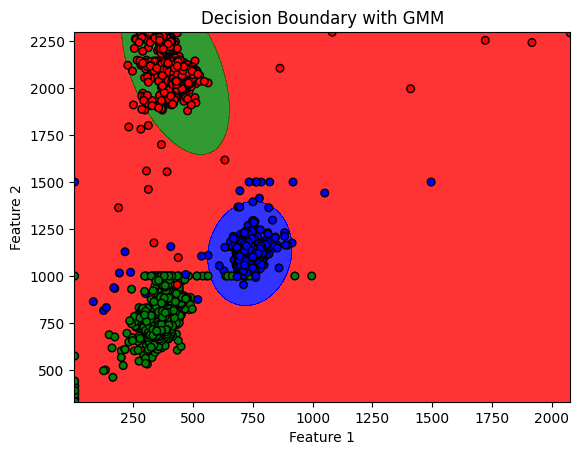

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, means, covariances, weights, resolution=0.5):
    # Define the grid for the plot with reduced resolution
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # Predict the class for each point on the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Ensure that the grid is not empty
    if grid_points.shape[0] == 0:
        raise ValueError("The generated grid points are empty. Check the resolution or data range.")

    # Predict the class labels for the grid points
    Z = predict_gmm(grid_points, means, covariances, weights)
    Z = Z.reshape(xx.shape)

    # Ensure that Z has at least a 2x2 shape
    if Z.shape[0] < 2 or Z.shape[1] < 2:
        raise ValueError(f"The predicted labels Z must be at least a (2, 2) shaped array, but has shape {Z.shape}")

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('red', 'green', 'blue')))

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o', s=30, cmap=ListedColormap(('red', 'green', 'blue')))
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title('Decision Boundary with GMM')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Example usage after fitting the GMM
plot_decision_boundary(X_train, y_train, means, covariances, weights, resolution=0.5)


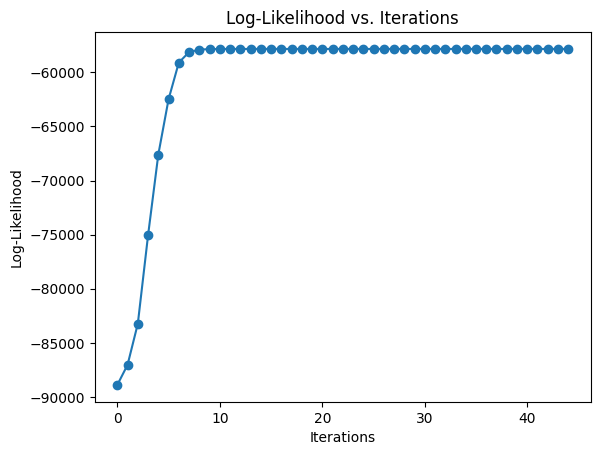

In [18]:
def plot_log_likelihood(likelihoods):
    plt.plot(range(len(likelihoods)), likelihoods, marker='o')
    plt.title('Log-Likelihood vs. Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Log-Likelihood')
    plt.show()

# Example usage after fitting the GMM
plot_log_likelihood(likelihoods)
